In [1]:
import pandas as pd

df= pd.read_csv("customer_shopping_behavior.csv")

# Customer Shopping Behavior Analysis

## Dataset Overview

This dataset contains retail customer shopping behavior information including demographics, purchase details, subscription status, discounts, shipping methods, and review ratings.

df.head()

## Initial Data Exploration

Understanding dataset structure, data types, and basic statistics.

df.info()

In [2]:
df.describe() #only numerical

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [3]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [4]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


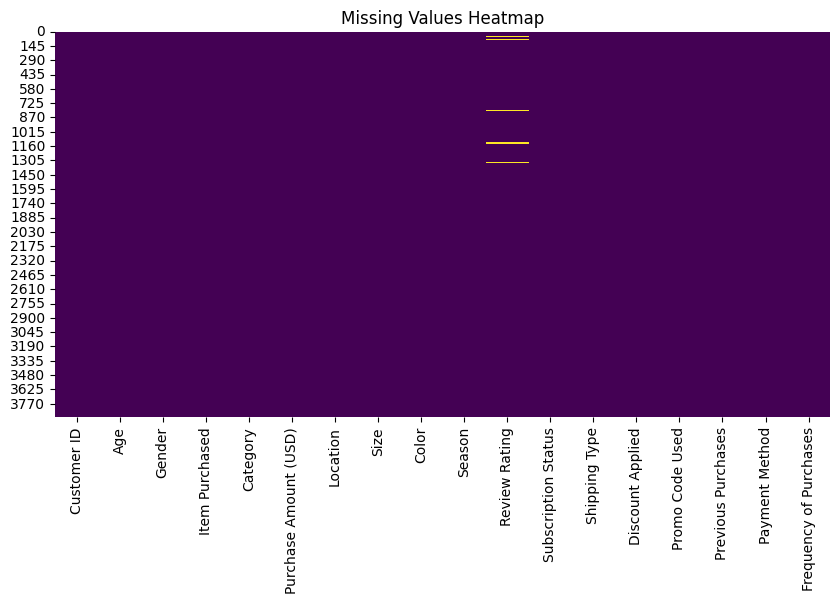

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [6]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [7]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [8]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('(', '')
df.columns = df.columns.str.replace(')', '')

print(df.columns)

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')


## Feature Engineering

Created new features to improve business analysis and customer segmentation.


In [9]:
#feature engineering
#create a column age_group
labels=['Young Adult','AAdult','Middle-aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels=labels)

In [10]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [11]:
# create column purchase_frequency_days

#created a dictionary:maps each textual frequency to no. of days
frequency_mapping={
    'Fortnightly':14,
    'weekly':7,
    'Monthly':30,
    'Quaterly':90,
    'Annually':365,
    'Bi-Annually':730,
    'Every 3 months':91,
    'Every 6 months':182,
    'Every 9 months':273,
    'Every year':365,
    '2 times a week':14,
    'Bi-Weekly':14,
    'Once':1
}

df['purchase_frequency_days']=df['frequency_of_purchases'].map(frequency_mapping)

In [12]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14.0,Fortnightly
1,14.0,Fortnightly
2,NaN,Weekly
3,NaN,Weekly
4,365.0,Annually
5,NaN,Weekly
6,NaN,Quarterly
7,NaN,Weekly
8,365.0,Annually
9,NaN,Quarterly


In [13]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [14]:
(df['discount_applied'] ==df['promo_code_used']).all() #check if need both the columns or not

np.True_

In [15]:
df=df.drop('promo_code_used',axis=1)

In [16]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

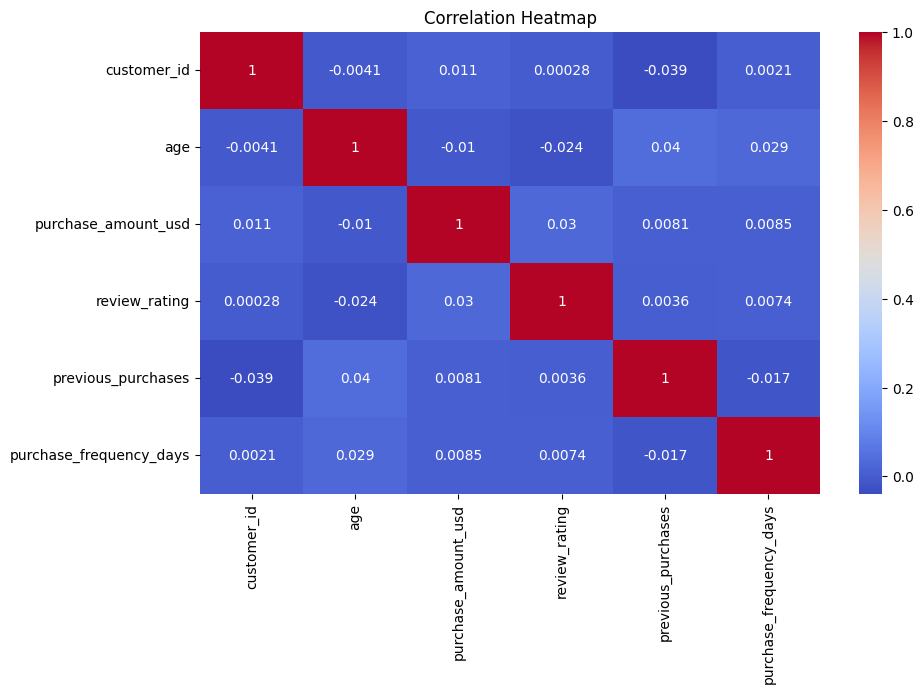

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

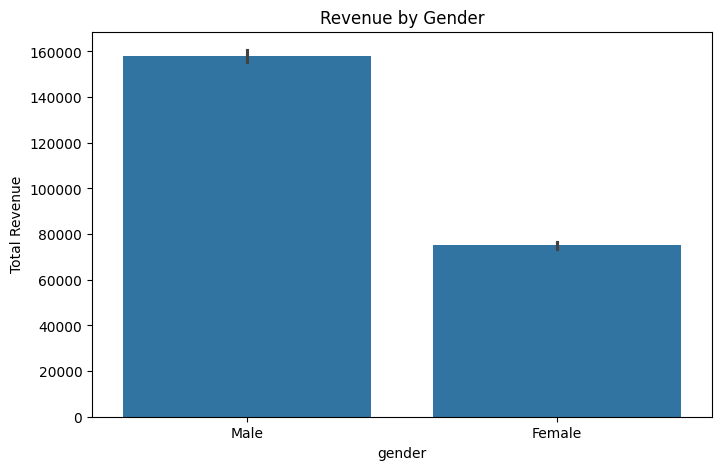

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='gender',
    y='purchase_amount_usd',
    data=df,
    estimator=sum
)

plt.title("Revenue by Gender")
plt.ylabel("Total Revenue")
plt.show()

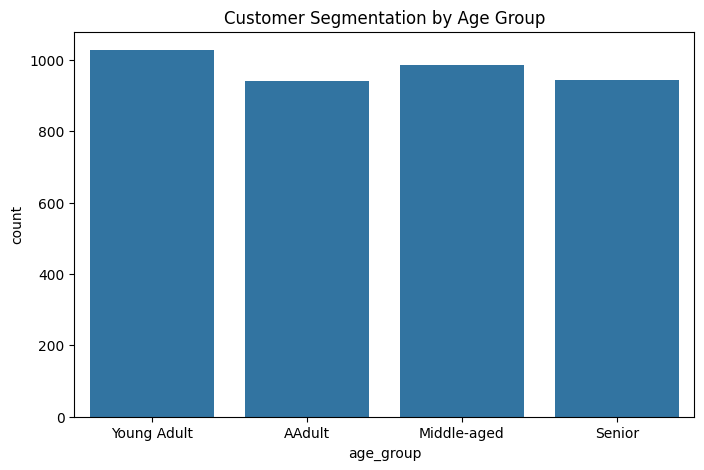

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='age_group',
    data=df
)

plt.title("Customer Segmentation by Age Group")
plt.show()

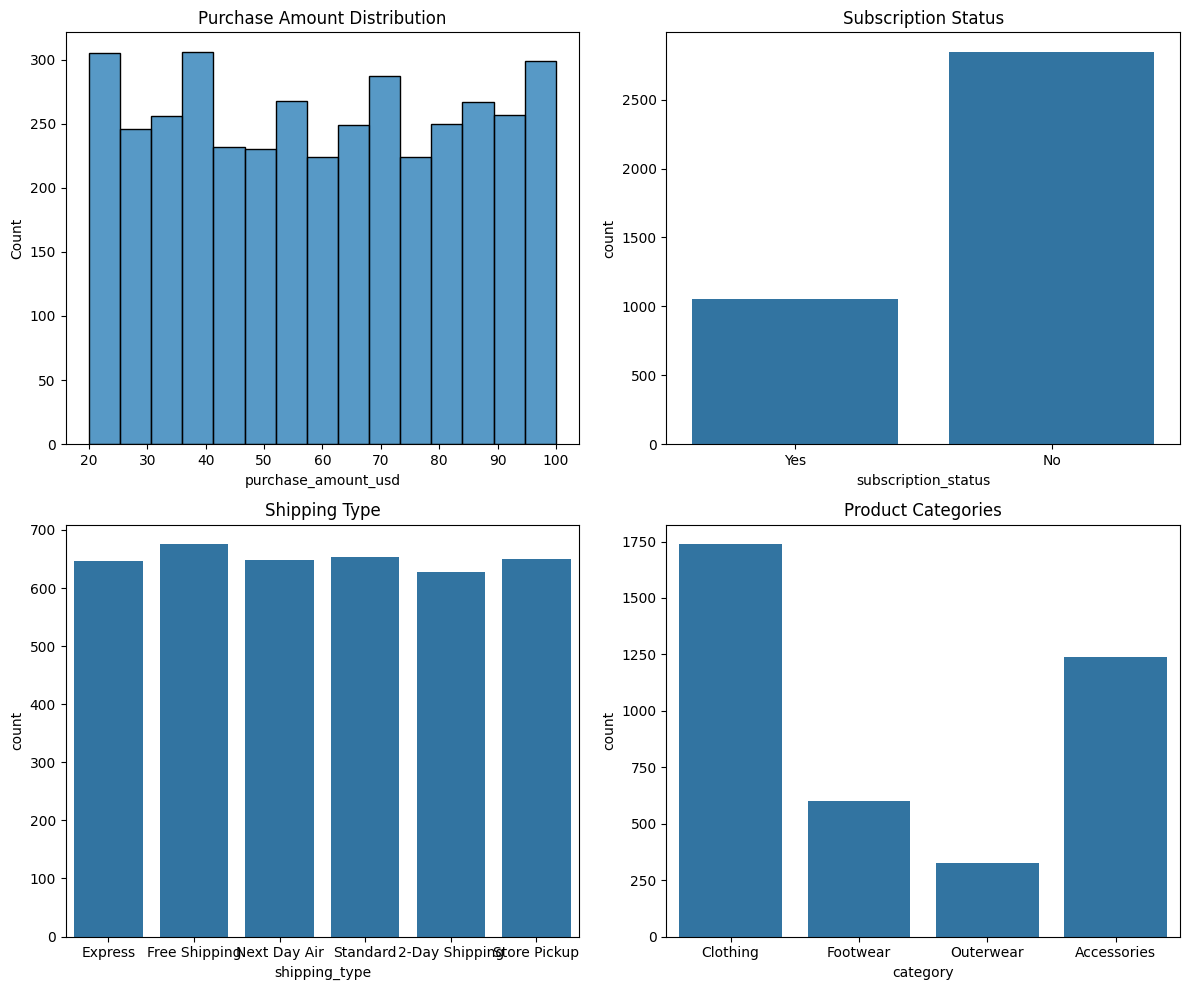

In [29]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.histplot(df['purchase_amount_usd'], ax=axes[0,0])
axes[0,0].set_title("Purchase Amount Distribution")

sns.countplot(x='subscription_status', data=df, ax=axes[0,1])
axes[0,1].set_title("Subscription Status")

sns.countplot(x='shipping_type', data=df, ax=axes[1,0])
axes[1,0].set_title("Shipping Type")

sns.countplot(x='category', data=df, ax=axes[1,1])
axes[1,1].set_title("Product Categories")

plt.tight_layout()
plt.show()

## SQL Integration

The cleaned dataset is loaded into MySQL for advanced business analysis using SQL queries.

In [17]:
#connect notebook to mysql

In [18]:
!pip install mysql-connector-python sqlalchemy pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.2 MB/s eta 0:00:00


In [19]:
#step 1: connect notebook to

In [20]:
# STEP i: Install Required Libraries
!pip install pymysql sqlalchemy

In [21]:
#step ii:Import Libraries
import pandas as pd
from sqlalchemy import create_engine

In [22]:
# STEP iii: MySQL Connection Details

username = 'root'
password = 'your_password'
host = 'localhost'
port = '3306'
database = 'customer_behavior'

In [23]:
# STEP iv: Create Engine

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

print("MySQL Connection Successful!")

MySQL Connection Successful!


In [24]:
#STEP 2: Load DataFrame into MySQL

In [25]:
from sqlalchemy import create_engine

table_name = 'customer'

df.to_sql(
    name=table_name,
    con=engine,
    if_exists='replace',   # replace existing table
    index=False
)

print("Data loaded successfully into MySQL!")

OperationalError: (pymysql.err.OperationalError) (2003, "Can't connect to MySQL server on 'localhost' ([Errno 111] Connection refused)")
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [ ]:
#read back sample
pd.read_sql("SELECT * FROM customer_behavior LIMIT 5;",engine)

# Final Insights

- Young adults were the most active shoppers
- Subscription customers showed better purchase consistency
- Discounts influenced purchasing behavior
- Certain product categories generated higher revenue
- Express shipping users had slightly higher purchase values